Training data shape: (1460, 81)
Testing data shape: (1459, 80)

Data preview:
   MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0          60       RL         65.0     8450   Pave   NaN      Reg   
1          20       RL         80.0     9600   Pave   NaN      Reg   
2          60       RL         68.0    11250   Pave   NaN      IR1   
3          70       RL         60.0     9550   Pave   NaN      IR1   
4          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
0         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
1         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
2         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
3         Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
4         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCond

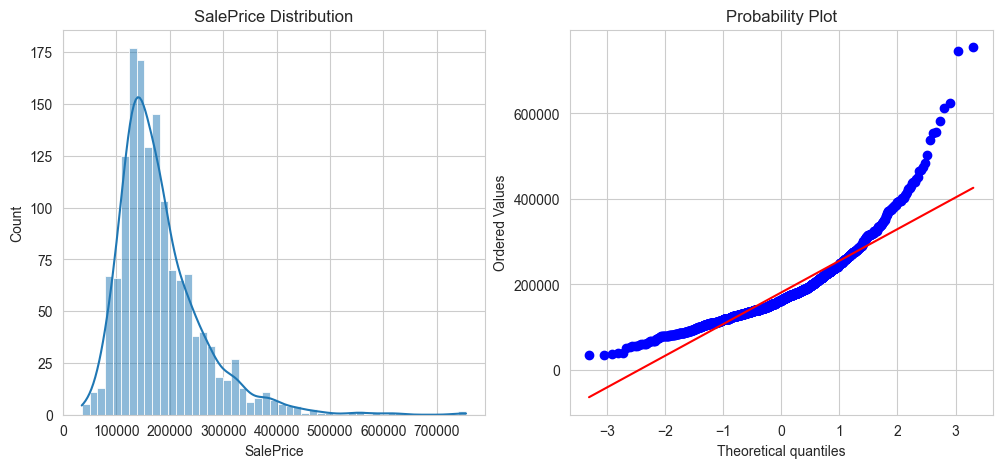

Skewness: 1.8829
Kurtosis: 6.5363


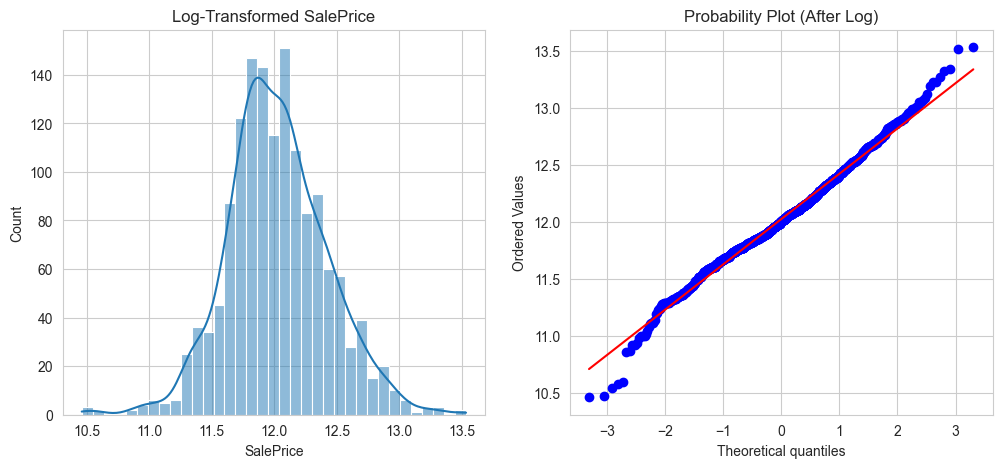

Skewness after log: 0.1213


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew

train = pd.read_csv(r'C:\Users\XUE\source\repos\Kaggle\houseP\houseP\house-prices-advanced-regression-techniques\train.csv')
test = pd.read_csv(r'C:\Users\XUE\source\repos\Kaggle\houseP\houseP\house-prices-advanced-regression-techniques\test.csv')

print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")
print()

train_ID = train['Id']
test_ID = test['Id']
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

print("Data preview:")
print(train.head())
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Probability Plot')

plt.show()

# 输出偏度和峰度，判断分布形态
print(f"Skewness: {train['SalePrice'].skew():.4f}")
print(f"Kurtosis: {train['SalePrice'].kurt():.4f}")

train['SalePrice'] = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Log-Transformed SalePrice')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Probability Plot (After Log)')
plt.show()

print(f"Skewness after log: {train['SalePrice'].skew():.4f}")

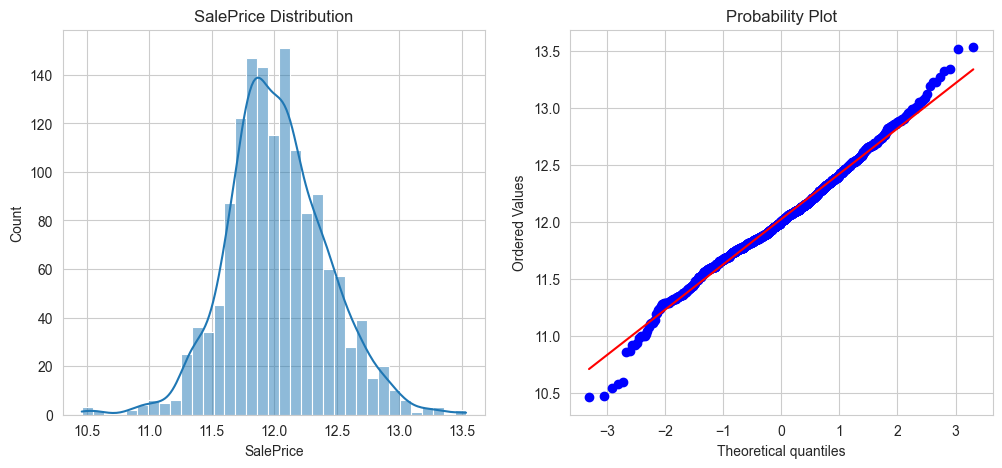

Skewness: 0.1213
Kurtosis: 0.8095


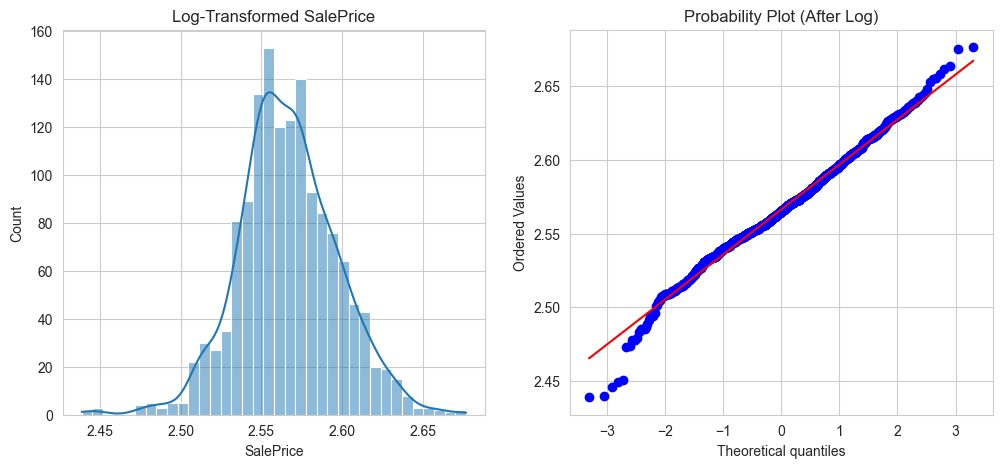

Skewness after log: -0.0092


In [ ]:

# 设置图表样式为白色网格背景
sns.set_style("whitegrid")
# 创建1行2列的子图，总尺寸宽12高5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：房价分布直方图 + 核密度曲线
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')

# 右图：正态概率图，检查是否服从正态分布
stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Probability Plot')

plt.show()

# 输出偏度（>0右偏）和峰度（>3尖峰）
print(f"Skewness: {train['SalePrice'].skew():.4f}")
print(f"Kurtosis: {train['SalePrice'].kurt():.4f}")

# 对房价取对数（log(1+x)），缓解偏态，使分布更接近正态
train['SalePrice'] = np.log1p(train['SalePrice'])

# 再次绘制变换后的分布和概率图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Log-Transformed SalePrice')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('Probability Plot (After Log)')
plt.show()

# 变换后偏度应接近0，说明正态性改善
print(f"Skewness after log: {train['SalePrice'].skew():.4f}")

In [5]:
#numeric
numeric_features = train.select_dtypes(include=[np.number]).columns
categorical_features = train.select_dtypes(include=['object']).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print()

Numeric features: 37
Categorical features: 43



C:\Users\xiaoh\AppData\Local\Temp\ipykernel_36600\1748359984.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include=['object']).columns


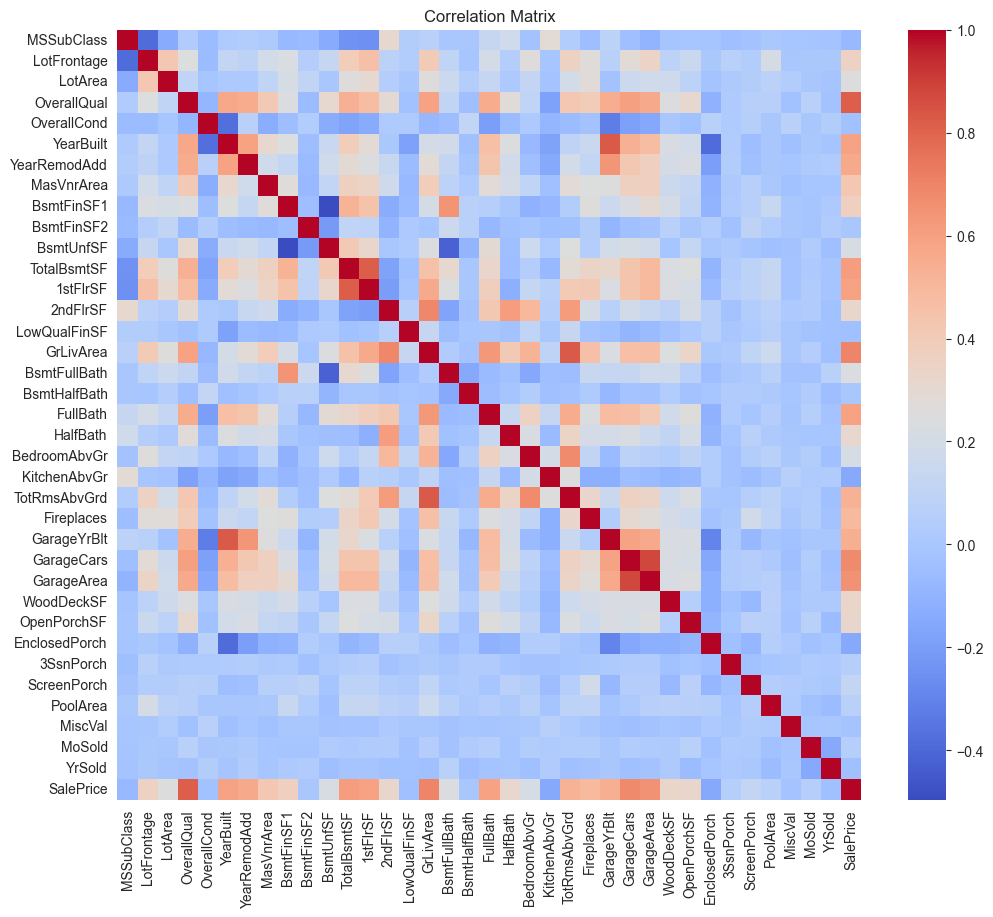

Top correlated features with SalePrice:
SalePrice       1.000000
OverallQual     0.815005
GrLivArea       0.697001
GarageCars      0.680156
GarageArea      0.649601
TotalBsmtSF     0.609138
FullBath        0.593950
1stFlrSF        0.593533
YearBuilt       0.587947
YearRemodAdd    0.566811
GarageYrBlt     0.542620
TotRmsAbvGrd    0.532015
Fireplaces      0.488470
MasVnrArea      0.425387
BsmtFinSF1      0.369589
Name: SalePrice, dtype: float64

Features with missing values:
              Train    Test
PoolQC         1453  1456.0
MiscFeature    1406  1408.0
Alley          1369  1352.0
Fence          1179  1169.0
MasVnrType      872   894.0
FireplaceQu     690   730.0
LotFrontage     259   227.0
GarageYrBlt      81    78.0
GarageFinish     81    78.0
GarageCond       81    78.0
GarageQual       81    78.0
GarageType       81    76.0
BsmtExposure     38    44.0
BsmtFinType2     38    42.0
BsmtCond         37    45.0
BsmtQual         37    44.0
BsmtFinType1     37    42.0
MasVnrArea        

In [ ]:
# 计算数值特征的相关系数矩阵
correlation_matrix = train[numeric_features].corr()
# 绘制热力图，coolwarm配色：红色正相关，蓝色负相关
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 提取与SalePrice相关系数最高的前15个特征（降序）
top_correlated = correlation_matrix['SalePrice'].sort_values(ascending=False).head(15)
print("Top correlated features with SalePrice:")
print(top_correlated)
print()

# 合并训练集和测试集的缺失值统计
missing_data = pd.concat([train.isnull().sum(), test.isnull().sum()], axis=1, keys=['Train', 'Test'])
# 只保留存在缺失值的特征
missing_data = missing_data[missing_data.sum(axis=1) > 0]
print("Features with missing values:")
# 按训练集缺失数量降序显示前20个
print(missing_data.sort_values('Train', ascending=False).head(20))

In [7]:
# fillna_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageYrBlt']

# train['PoolQC'] = train['PoolQC'].fillna(0)
# test['PoolQC'] = test['PoolQC'].fillna(0)

In [ ]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice']
all_data = pd.concat([train.drop('SalePrice', axis=1), test]).reset_index(drop=True) # 将训练集（去掉SalePrice列）和测试集纵向拼接，用于统一预处理
print(all_data)

      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0             60       RL         65.0     8450   Pave   NaN      Reg   
1             20       RL         80.0     9600   Pave   NaN      Reg   
2             60       RL         68.0    11250   Pave   NaN      IR1   
3             70       RL         60.0     9550   Pave   NaN      IR1   
4             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
2914         160       RM         21.0     1936   Pave   NaN      Reg   
2915         160       RM         21.0     1894   Pave   NaN      Reg   
2916          20       RL        160.0    20000   Pave   NaN      Reg   
2917          85       RL         62.0    10441   Pave   NaN      Reg   
2918          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC  Fence  \
0            Lvl    AllPub    Inside  ...  

In [9]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['Has2ndFloor'] = all_data['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasGarage'] = all_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasBasement'] = all_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasFireplace'] = all_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# 数值型缺失：用0填充（表示无车库、无 masonry 面积）
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea'):
    all_data[col] = all_data[col].fillna(0)

# 类别型缺失：用 'None' 填充（表示无此特征）
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 
            'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'):
    all_data[col] = all_data[col].fillna('None')

# 地下室相关数值特征：缺失视为0（表示无地下室面积或设施）
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

# 以下类别特征：用众数填充（最常见的取值）
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['Functional'] = all_data['Functional'].fillna(all_data['Functional'].mode()[0])

In [11]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str) #含数字的feature不一定有数字的逻辑
all_data['OverallCond'] = all_data['OverallCond'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)
all_data = all_data.fillna(all_data.mode().iloc[0])
print(f"Missing values after imputation: {all_data.isnull().sum().sum()}")

Missing values after imputation: 0


In [ ]:
# 筛选数值型特征
numeric_features = all_data.select_dtypes(include=[np.number]).columns
# 计算每个数值特征的偏度，保留偏度绝对值 > 0.75 的特征（强偏态）
skewed_features = all_data[numeric_features].apply(lambda x: skew(x.dropna()))
skewed_features = skewed_features[abs(skewed_features) > 0.75].index

from scipy.special import boxcox1p
lam = 0.15  # Box-Cox 变换参数（固定值）
# 对每个偏态特征应用 Box-Cox 变换（1p 版本适用于含零值的数据）
for feature in skewed_features:
    all_data[feature] = boxcox1p(all_data[feature], lam)

print(f"Skewed features transformed: {len(skewed_features)}")
print()

# 对类别特征进行独热编码（生成虚拟变量）
all_data = pd.get_dummies(all_data)
print(f"Shape after encoding: {all_data.shape}")

Skewed features transformed: 27

Shape after encoding: (2919, 343)


In [13]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 2.9 MB/s eta 0:00:35
   - -------------------------------------- 2.9/101.7 MB 5.5 MB/s eta 0:00:18
   --- ------------------------------------ 7.9/101.7 MB 11.1 MB/s eta 0:00:09
   -------- ------------------------------- 21.0/101.7 MB 23.2 MB/s eta 0:00:04
   ----------------- ---------------------- 44.8/101.7 MB 40.7 MB/s eta 0:00:02
   --------------------------- ------------ 68.9/101.7 MB 53.0 MB/s eta 0:00:01
   ------------------------------------- -- 94.6/101.7 MB 63.0 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 60.1 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

n_folds = 5
def rmsle_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42) #交叉验证
    rmse = np.sqrt(-cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=kf))
    return rmse


# Lasso：线性模型，RobustScaler 抗异常值，alpha 很小（几乎不惩罚）
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42))
# ElasticNet：结合 L1+L2，l1_ratio=0.9 偏重 L1
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42))
# 核岭回归：多项式核，适合捕捉非线性趋势
KRR = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)
# GBDT：大量树(3000)，低学习率，Huber loss 对异常值鲁棒
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05, max_depth=4,
                                   max_features='sqrt', min_samples_leaf=15,
                                   min_samples_split=10, loss='huber', random_state=42)
# XGBoost：参数经过调优，包含 L1/L2 正则，子采样
model_xgb = xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, learning_rate=0.05,
                             max_depth=3, min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571, subsample=0.5213,
                             random_state=42, nthread=-1)
# LightGBM：叶子数少(5)防过拟合，特征/样本采样比例低
model_lgb = lgb.LGBMRegressor(objective='regression', num_leaves=5, learning_rate=0.05,
                              n_estimators=720, max_bin=55, bagging_fraction=0.8,
                              bagging_freq=5, feature_fraction=0.2319, feature_fraction_seed=9,
                              bagging_seed=9, min_data_in_leaf=6, min_sum_hessian_in_leaf=11)
print("Model Performance (RMSLE):")
print(f"Lasso: {rmsle_cv(lasso).mean():.4f}")
print(f"ElasticNet: {rmsle_cv(ENet).mean():.4f}")
print(f"Kernel Ridge: {rmsle_cv(KRR).mean():.4f}") 
print(f"Gradient Boosting: {rmsle_cv(GBoost).mean():.4f}")
print(f"XGBoost: {rmsle_cv(model_xgb).mean():.4f}")
print(f"LightGBM: {rmsle_cv(model_lgb).mean():.4f}")

Model Performance (RMSLE):
Lasso: 0.0116
ElasticNet: 0.0115
Kernel Ridge: 0.0154
Gradient Boosting: 0.0097
XGBoost: 0.0192
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_b

In [16]:
print("Model Performance (RMSLE):")
print(f"Lasso: {rmsle_cv(lasso).mean():.4f}")
print(f"ElasticNet: {rmsle_cv(ENet).mean():.4f}")
print(f"Kernel Ridge: {rmsle_cv(KRR).mean():.4f}")
print(f"Gradient Boosting: {rmsle_cv(GBoost).mean():.4f}")
print(f"XGBoost: {rmsle_cv(model_xgb).mean():.4f}")
print(f"LightGBM: {rmsle_cv(model_lgb).mean():.4f}")

Model Performance (RMSLE):
Lasso: 0.0116
ElasticNet: 0.0115
Kernel Ridge: 0.0154
Gradient Boosting: 0.0097
XGBoost: 0.0192
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_b

In [ ]:
# 自定义模型集成类：对多个模型的预测结果进行简单平均
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models          # 存储待集成的模型列表

    def fit(self, X, y):
        # 克隆每个模型（避免后续修改原始模型）
        self.models_ = [clone(x) for x in self.models]
        # 分别训练每个模型
        for model in self.models_:
            model.fit(X, y)
        return self

    def predict(self, X):
        # 收集所有模型的预测结果（列方向堆叠）
        predictions = np.column_stack([model.predict(X) for model in self.models_])
        # 按行取平均值作为最终预测
        return np.mean(predictions, axis=1)

# 将四个基础模型进行平均集成：ElasticNet、GradientBoosting、KernelRidge、Lasso
averaged_models = AveragingModels(models=(ENet, GBoost, KRR, lasso))
# 输出集成模型的交叉验证 RMSLE
print(f"Averaged models RMSLE: {rmsle_cv(averaged_models).mean():.4f}")

Averaged models RMSLE: 0.0106


In [18]:
#numeric
numeric_features = train.select_dtypes(include=[np.number]).columns
categorical_features = train.select_dtypes(include=['object']).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print()

Numeric features: 37
Categorical features: 43



C:\Users\xiaoh\AppData\Local\Temp\ipykernel_36600\1748359984.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include=['object']).columns


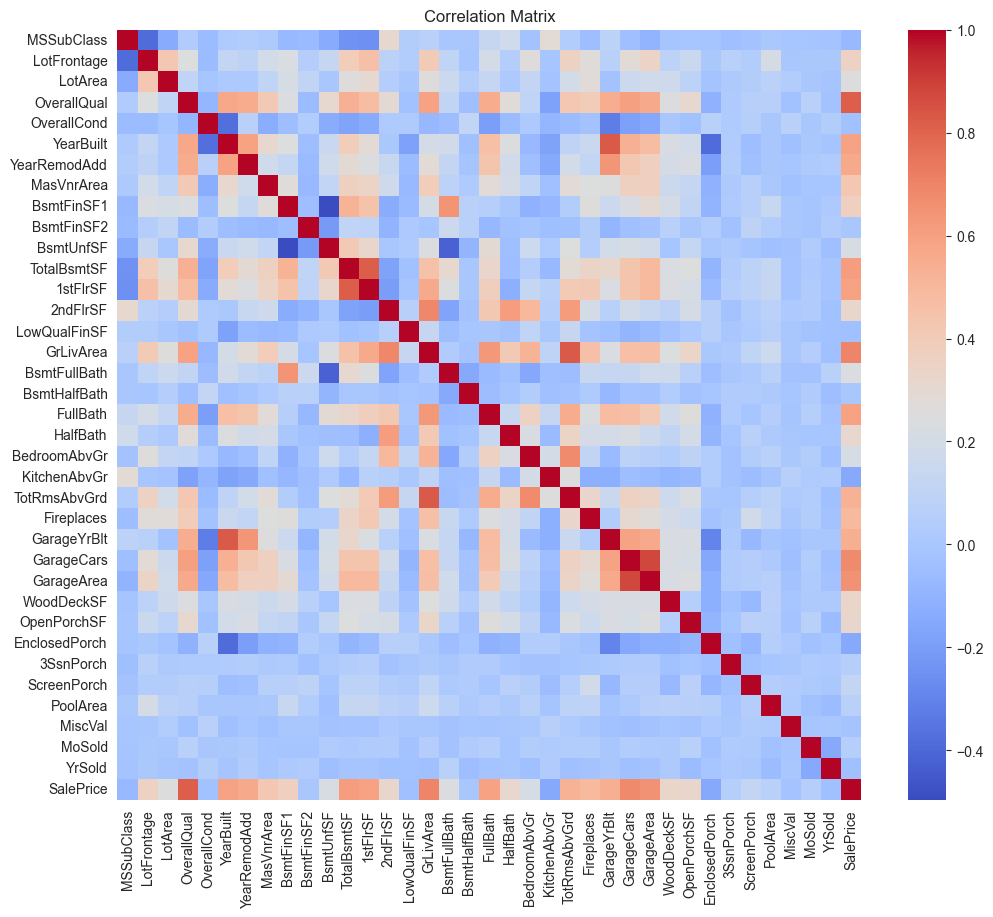

Top correlated features with SalePrice:
SalePrice       1.000000
OverallQual     0.815005
GrLivArea       0.697001
GarageCars      0.680156
GarageArea      0.649601
TotalBsmtSF     0.609138
FullBath        0.593950
1stFlrSF        0.593533
YearBuilt       0.587947
YearRemodAdd    0.566811
GarageYrBlt     0.542620
TotRmsAbvGrd    0.532015
Fireplaces      0.488470
MasVnrArea      0.425387
BsmtFinSF1      0.369589
Name: SalePrice, dtype: float64

Features with missing values:
              Train    Test
PoolQC         1453  1456.0
MiscFeature    1406  1408.0
Alley          1369  1352.0
Fence          1179  1169.0
MasVnrType      872   894.0
FireplaceQu     690   730.0
LotFrontage     259   227.0
GarageYrBlt      81    78.0
GarageFinish     81    78.0
GarageCond       81    78.0
GarageQual       81    78.0
GarageType       81    76.0
BsmtExposure     38    44.0
BsmtFinType2     38    42.0
BsmtCond         37    45.0
BsmtQual         37    44.0
BsmtFinType1     37    42.0
MasVnrArea        

In [19]:
correlation_matrix = train[numeric_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

top_correlated = correlation_matrix['SalePrice'].sort_values(ascending=False).head(15)
print("Top correlated features with SalePrice:")
print(top_correlated)
print()

missing_data = pd.concat([train.isnull().sum(), test.isnull().sum()], axis=1, keys=['Train', 'Test'])
missing_data = missing_data[missing_data.sum(axis=1) > 0]
print("Features with missing values:")
print(missing_data.sort_values('Train', ascending=False).head(20))

In [20]:
# fillna_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageYrBlt']

# train['PoolQC'] = train['PoolQC'].fillna(0)
# test['PoolQC'] = test['PoolQC'].fillna(0)

In [21]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice']
all_data = pd.concat([train.drop('SalePrice', axis=1), test]).reset_index(drop=True)
print(all_data)

      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0             60       RL         65.0     8450   Pave   NaN      Reg   
1             20       RL         80.0     9600   Pave   NaN      Reg   
2             60       RL         68.0    11250   Pave   NaN      IR1   
3             70       RL         60.0     9550   Pave   NaN      IR1   
4             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
2914         160       RM         21.0     1936   Pave   NaN      Reg   
2915         160       RM         21.0     1894   Pave   NaN      Reg   
2916          20       RL        160.0    20000   Pave   NaN      Reg   
2917          85       RL         62.0    10441   Pave   NaN      Reg   
2918          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC  Fence  \
0            Lvl    AllPub    Inside  ...  

In [22]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['Has2ndFloor'] = all_data['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasGarage'] = all_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasBasement'] = all_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasFireplace'] = all_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

In [23]:
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea'):
    all_data[col] = all_data[col].fillna(0)
    
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 
            'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'):
    all_data[col] = all_data[col].fillna('None')
    
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)
    
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['Functional'] = all_data['Functional'].fillna(all_data['Functional'].mode()[0])

In [24]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str) #含数字的feature不一定有数字的逻辑
all_data['OverallCond'] = all_data['OverallCond'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)
all_data = all_data.fillna(all_data.mode().iloc[0])
print(f"Missing values after imputation: {all_data.isnull().sum().sum()}")

Missing values after imputation: 0


In [25]:
#偏态特征 ：大部分模型是基于正态分布，所以把数据修正
numeric_features = all_data.select_dtypes(include=[np.number]).columns
skewed_features = all_data[numeric_features].apply(lambda x: skew(x.dropna()))
skewed_features = skewed_features[abs(skewed_features) > 0.75].index

from scipy.special import boxcox1p
lam = 0.15
for feature in skewed_features:
    all_data[feature] = boxcox1p(all_data[feature], lam)
    
print(f"Skewed features transformed: {len(skewed_features)}")
print()

all_data = pd.get_dummies(all_data)
print(f"Shape after encoding: {all_data.shape}")

Skewed features transformed: 27

Shape after encoding: (2919, 343)


In [26]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

n_folds = 5
def rmsle_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=kf))
    return rmse
                        
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42))
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42))  
KRR = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05, max_depth=4,  
                                   max_features='sqrt', min_samples_leaf=15, 
                                   min_samples_split=10, loss='huber', random_state=42)
model_xgb = xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, learning_rate=0.05, #gamma:
                             max_depth=3, min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571, subsample=0.5213, 
                             random_state=42, nthread=-1) #能用xgb就用xgb
model_lgb = lgb.LGBMRegressor(objective='regression', num_leaves=5, learning_rate=0.05, 
                              n_estimators=720, max_bin=55, bagging_fraction=0.8,
                              bagging_freq=5, feature_fraction=0.2319, feature_fraction_seed=9,
                              bagging_seed=9, min_data_in_leaf=6, min_sum_hessian_in_leaf=11) 

print("Model Performance (RMSLE):")
print(f"Lasso: {rmsle_cv(lasso).mean():.4f}")
print(f"ElasticNet: {rmsle_cv(ENet).mean():.4f}")
print(f"Kernel Ridge: {rmsle_cv(KRR).mean():.4f}") 
print(f"Gradient Boosting: {rmsle_cv(GBoost).mean():.4f}")
print(f"XGBoost: {rmsle_cv(model_xgb).mean():.4f}")
print(f"LightGBM: {rmsle_cv(model_lgb).mean():.4f}")

Model Performance (RMSLE):
Lasso: 0.0116
ElasticNet: 0.0115
Kernel Ridge: 0.0154
Gradient Boosting: 0.0097
XGBoost: 0.0192
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_b

In [29]:
print("Model Performance (RMSLE):")
print(f"Lasso: {rmsle_cv(lasso).mean():.4f}")
print(f"ElasticNet: {rmsle_cv(ENet).mean():.4f}")
print(f"Kernel Ridge: {rmsle_cv(KRR).mean():.4f}")
print(f"Gradient Boosting: {rmsle_cv(GBoost).mean():.4f}")
print(f"XGBoost: {rmsle_cv(model_xgb).mean():.4f}")
print(f"LightGBM: {rmsle_cv(model_lgb).mean():.4f}")

Model Performance (RMSLE):
Lasso: 0.0116
ElasticNet: 0.0115
Kernel Ridge: 0.0154
Gradient Boosting: 0.0097
XGBoost: 0.0192
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_b

In [30]:
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin): 
    def __init__(self, models):
        self.models = models
        
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models] #clone拟合以后不会污染最开始的模型
        for model in self.models_:
            model.fit(X, y)
        return self
    
    def predict(self, X):
        predictions = np.column_stack([model.predict(X) for model in self.models_])
        return np.mean(predictions, axis=1) 

averaged_models = AveragingModels(models=(ENet, GBoost, KRR, lasso))
print(f"Averaged models RMSLE: {rmsle_cv(averaged_models).mean():.4f}") 

Averaged models RMSLE: 0.0106


Training final models...
Final model training RMSLE: 0.0020
Submission file created: submission.csv


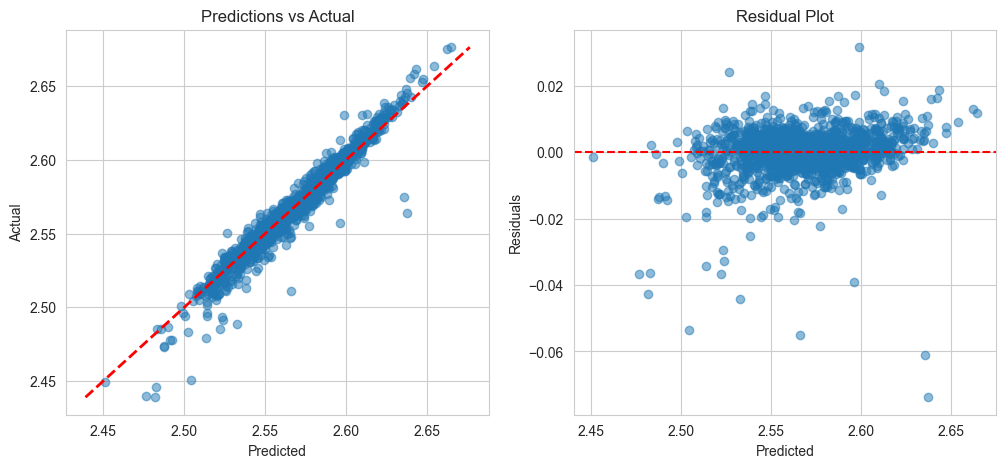

In [ ]:
# 定义 RMSLE 评估指标（PS:  Kaggle 官方要求：对预测值和真实值先取 log1p，再计算 RMSE）
def rmsle(y, y_pred):
    return np.sqrt(np.mean((np.log1p(y) - np.log1p(y_pred))**2))

print("Training final models...")
# 使用前面定义的平均集成模型（ENet, GBoost, KRR, lasso）
final_model = averaged_models
# 用全部训练数据重新训练（不再做交叉验证）
final_model.fit(X_train, y_train)

# 训练集预测（用于查看拟合程度）和测试集预测（用于提交）
final_train_pred = final_model.predict(X_train)
final_pred = final_model.predict(X_test)

# 输出训练集上的 RMSLE（注意这里只是训练误差，不代表泛化能力，可能偏低）
print(f"Final model training RMSLE: {rmsle(y_train, final_train_pred):.4f}")

# 生成提交文件
submission = pd.DataFrame()
submission['Id'] = test_ID          # 测试集的 Id（之前保存过）
submission['SalePrice'] = final_pred  # 注意这里直接输出预测值（原始房价？但 y_train 取过 log，预测值也在 log 空间？需要确认）
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")

# 绘制预测值 vs 真实值散点图 + 残差图，用于诊断模型拟合质量
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 左图：预测值 vs 真实值（点应贴近对角线）
axes[0].scatter(final_train_pred, y_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Predictions vs Actual')

# 右图：残差图（残差 = 真实值 - 预测值），应随机分布在零线附近
residuals = y_train - final_train_pred
axes[1].scatter(final_train_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
plt.show()